# Metodos de busqueda por medio de Optimización Bayesiana

|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña |
| **Fecha**      | 23/03/2026 |
| **Expediente** |  757048 | 

### Datos Iniciales

In [25]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Datos iniciales
X = np.array([[10.0], [2.0], [3.0]])   # shape (n, 1)
y = np.array([2847.0, -4017.0, -1255.0])    

# Crear y entrenar el GP
kernel = RBF(length_scale=1.0)
modelo_gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
modelo_gp.fit(X, y)

# x_sim: rango de valores a predecir
X_sim = np.linspace(2, 15, 1001).reshape(-1, 1)  # shape (1001, 1)

# y_hat: predicción del surrogate
Y_hat, sigma = modelo_gp.predict(X_sim, return_std=True)



c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Grafico

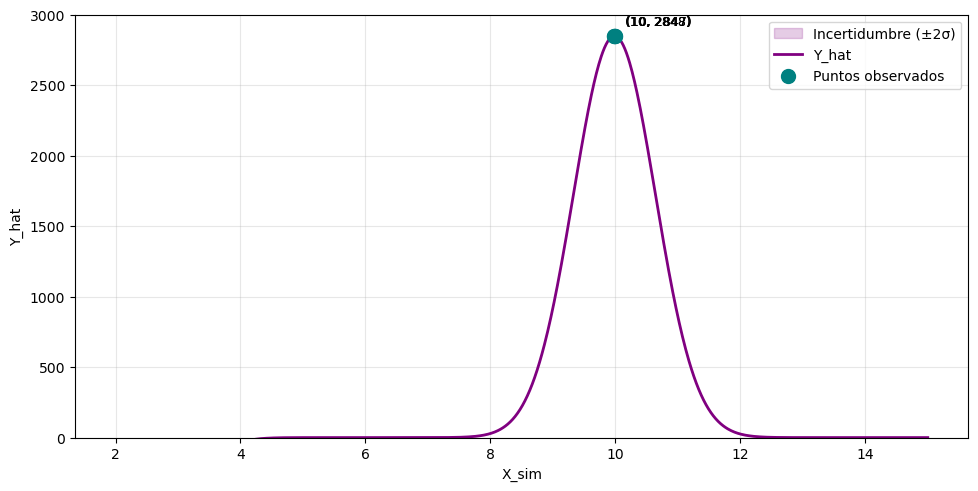

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(X_sim.ravel(), Y_hat - 2*sigma, Y_hat + 2*sigma,
                alpha=0.2, color='purple', label='Incertidumbre (±2σ)')

ax.plot(X_sim, Y_hat, color='purple', linewidth=2, label='Y_hat')

ax.scatter(X, y, color='teal', s=100, zorder=5, label='Puntos observados')

for xi, yi in zip(X.ravel(), y):
    ax.annotate(f'({xi:.0f}, {yi:.0f})', xy=(xi, yi),
                xytext=(8, 8), textcoords='offset points', fontsize=9)

ax.set_xlabel('X_sim')
ax.set_ylabel('Y_hat')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
ax.set_ylim([0, 3000]) #el valor positivo
plt.show()

### Buscas el Maximo con la X_simulada y Y_predicha

In [39]:
idx   = np.argmax(Y_hat)
X_sim[idx]
Y_hat[idx]


2847.672330888756

### Con esos nuevos datos vuelves a hacer el proceso

In [40]:
# nuevo punto observado
x_new = np.array([[9.982]])
y_new = np.array([2847.672330888756])

# agregar a los datos originales
X = np.append(X, x_new, axis=0)
y = np.append(y, y_new)

# reentrenar el GP con 4 puntos
modelo_gp.fit(X, y)

# nueva predicción
Y_hat, sigma = modelo_gp.predict(X_sim, return_std=True)

In [41]:
idx   = np.argmax(Y_hat)
x_new = X_sim[idx][0]
y_new = Y_hat[idx]

print(f"x_new : {x_new}")
print(f"y_hat : {y_new}")

x_new : 9.982
y_hat : 2847.6723308888254


### Cada vez se acerca mas al maximo real, en teoria si lo haces lo suficiente llegas

In [42]:
x_new2 = np.array([[9.982]])
y_new2 = np.array(2847.6723308888254)

# agregar a los datos originales
X = np.append(X, x_new2, axis=0)
y = np.append(y, y_new2)

# reentrenar el GP con 4 puntos
modelo_gp.fit(X, y)

# nueva predicción
Y_hat, sigma = modelo_gp.predict(X_sim, return_std=True)

In [44]:
idx   = np.argmax(Y_hat)
print(f"x_new3 : {X_sim[idx][0]}")
print(f"y_hat  : {Y_hat[idx]}")

x_new3 : 9.982
y_hat  : 2847.672330888825
